In [74]:
from pathlib import Path
from typing import Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
tqdm.pandas()

In [75]:
def find_project_root(start: Optional[Path] = None) -> Path:
    start = start or Path.cwd()
    candidates = [start, start.parent]

    for candidate in candidates:
        if (candidate / 'data' / 'images' / 'orga_widecrop').exists():
            return candidate
        
    raise FileNotFoundError('Impossible de trouver la racine du projet à partir de la position courante.')

In [76]:
PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / 'data' / 'images'
WIDE_ROOT = DATA_ROOT / 'orga_widecrop'
CROP_ROOT = DATA_ROOT / 'orga_cropping'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'manifests'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Racine du projet : {PROJECT_ROOT}')
print(f'Wide root : {WIDE_ROOT}')
print(f'Crop root : {CROP_ROOT}')

Racine du projet : c:\Users\Jules\Documents\IEES\idmybee
Wide root : c:\Users\Jules\Documents\IEES\idmybee\data\images\orga_widecrop
Crop root : c:\Users\Jules\Documents\IEES\idmybee\data\images\orga_cropping


## Inventaire des images

In [77]:
def build_manifest() -> pd.DataFrame:
    rows = []

    for species_dir in sorted(WIDE_ROOT.iterdir()):
        if not species_dir.is_dir() or species_dir.name == 'Vrac':
            continue

        species = species_dir.name

        for role_dir in sorted(species_dir.iterdir()):
            if not role_dir.is_dir():
                continue

            role = role_dir.name
            wide_dir = WIDE_ROOT / species / role
            crop_dir = CROP_ROOT / species / role
            wide_files = {p.name for p in wide_dir.glob('*') if p.is_file()}
            crop_files = {p.name for p in crop_dir.glob('*') if p.is_file()}

            for name in sorted(wide_files | crop_files):
                wide_path = wide_dir / name
                crop_path = crop_dir / name
                has_wide = wide_path.exists()
                has_crop = crop_path.exists()

                pid = Path(name).stem
                appareil = pid.split('_')[1]

                rows.append({
                    'id': pid,
                    'espece': species,
                    'role': role,
                    'appareil': appareil,
                    'chemin_wide': wide_path.relative_to(PROJECT_ROOT).as_posix() if has_wide else None,
                    'chemin_crop_large': crop_path.relative_to(PROJECT_ROOT).as_posix() if has_crop else None,
                    'statut': None,
                    'diff_score': np.nan,
                    'match_score': np.nan,
                    'area_ratio': np.nan,
                })

    manifest = pd.DataFrame(rows).sort_values(['espece', 'role', 'id']).reset_index(drop=True)
    return manifest

manifest = build_manifest()
manifest.head()

,id,espece,role,appareil,chemin_wide,chemin_crop_large,statut,diff_score
0,FR15ABOM150820018_P1,Bombus_confusus,male,P1,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,None,NaN
1,FR15ABOM150820018_P2,Bombus_confusus,male,P2,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,None,NaN
2,FR15ABOM150820018_S1,Bombus_confusus,male,S1,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,None,NaN
3,FR15ABOM150820018_S2,Bombus_confusus,male,S2,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,None,NaN
4,FR15ABOM150820018_S3,Bombus_confusus,male,S3,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,None,NaN


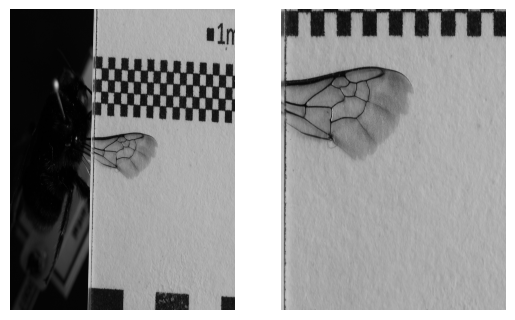

(0.2760740792928509, 0.7239259207071491, 1.0)

In [94]:
pair = manifest.set_index("id").loc["FR15_ABOM080820007_P1"]

wide_path = PROJECT_ROOT / pair["chemin_wide"]
crop_path = PROJECT_ROOT / pair['chemin_crop_large']

wide = cv2.imread(str(wide_path), cv2.IMREAD_COLOR)
crop = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)

if wide is None or crop is None:
    raise ValueError(f"Impossible de lire les images pour {pair['id']}")

wide_gray = cv2.cvtColor(wide, cv2.COLOR_BGR2GRAY)
crop_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

hist_wide = cv2.calcHist([wide_gray], [0], None, [32], [0, 256]).flatten()
hist_crop = cv2.calcHist([crop_gray], [0], None, [32], [0, 256]).flatten()
hist_wide = hist_wide / hist_wide.sum()
hist_crop = hist_crop / hist_crop.sum()
hist_corr = float(cv2.compareHist(hist_wide, hist_crop, cv2.HISTCMP_CORREL))

if crop_gray.shape[0] <= wide_gray.shape[0] and crop_gray.shape[1] <= wide_gray.shape[1]:
    template_score = float(cv2.matchTemplate(wide_gray, crop_gray, cv2.TM_CCOEFF_NORMED).max())
else:
    template_score = np.nan

area_ratio = crop_gray.shape[0] * crop_gray.shape[1] / max(1, wide_gray.shape[0] * wide_gray.shape[1])
match_score = float(np.nanmean([template_score, hist_corr])) if not np.isnan(template_score) else hist_corr

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(cv2.cvtColor(wide_gray, cv2.COLOR_BGR2RGB))
ax2.imshow(cv2.cvtColor(crop_gray, cv2.COLOR_BGR2RGB))
ax1.set_title('Wide')
ax2.set_title('Crop')
for ax in (ax1, ax2):
    ax.axis('off')
plt.tight_layout()
plt.show()

match_score, area_ratio, hist_corr

In [ ]:
def compute_diff_score(wide_path: Path, crop_path: Path) -> tuple[float, float, float]:
    wide = cv2.imread(str(wide_path), cv2.IMREAD_COLOR)
    crop = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)

    if wide is None or crop is None:
        return np.nan, np.nan, np.nan

    wide_gray = cv2.cvtColor(wide, cv2.COLOR_BGR2GRAY)
    crop_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    area_ratio = crop_gray.shape[0] * crop_gray.shape[1] / max(1, wide_gray.shape[0] * wide_gray.shape[1])
    match_score = float(area_ratio)
    diff_score = float(1.0 - match_score)

    return diff_score, match_score, area_ratio


def classify_status(row: pd.Series) -> tuple[str, float, float, float]:
    has_wide = pd.notna(row['chemin_wide'])
    has_crop = pd.notna(row['chemin_crop_large'])

    if has_crop and not has_wide:
        return 'crop_sans_wide', np.nan, np.nan, np.nan
    if has_wide and not has_crop:
        return 'wide_non_crope', np.nan, np.nan, np.nan
    if not has_wide and not has_crop:
        return 'inexploitable', np.nan, np.nan, np.nan

    wide_path = PROJECT_ROOT / row['chemin_wide']
    crop_path = PROJECT_ROOT / row['chemin_crop_large']
    diff_score, match_score, area_ratio = compute_diff_score(wide_path, crop_path)

    if np.isnan(diff_score):
        return 'inexploitable', diff_score, match_score, area_ratio

    if area_ratio >= 0.85:
        return 'wide_non_crope', diff_score, match_score, area_ratio
    if area_ratio <= 0.35:
        return 'paire_exploitable', diff_score, match_score, area_ratio
    return 'wide_recadre_leger', diff_score, match_score, area_ratio

In [98]:
manifest[['statut', 'diff_score', 'match_score', 'area_ratio']] = manifest.progress_apply(classify_status, axis=1, result_type='expand')

print(manifest['statut'].value_counts(dropna=False).to_string())
print('\nExemples de paires recadrées légères :')
print(manifest[manifest['statut'] == 'wide_recadre_leger'][['id', 'espece', 'role', 'diff_score', 'match_score', 'area_ratio']].head(10).to_string(index=False))

100%|██████████| 2615/2615 [15:16<00:00,  2.85it/s]

statut
wide_non_crope        892
wide_recadre_leger    831
paire_exploitable     831
crop_sans_wide         61

Exemples de paires recadrées légères :
                  id          espece role  diff_score  match_score  area_ratio
FR15ABOM150820018_P1 Bombus_confusus male    0.241988     0.758012    0.237583
FR15ABOM150820018_P2 Bombus_confusus male    0.234492     0.765508    0.234155
FR15ABOM150820018_S1 Bombus_confusus male    0.026768     0.973232    0.363868
FR15ABOM150820018_S2 Bombus_confusus male    0.027115     0.972885    0.396560
FR15ABOM150820018_S3 Bombus_confusus male    0.024092     0.975908    0.396768
FR15ABOM170821029_P2 Bombus_confusus male    0.166675     0.833325    0.242653
FR15ABOM170821029_S1 Bombus_confusus male    0.031118     0.968882    0.399208
FR15ABOM170821029_S2 Bombus_confusus male    0.180523     0.819477    0.391359
FR15ABOM170821029_S3 Bombus_confusus male    0.270241     0.729759    0.404952
FR15ABOM210821137_P1 Bombus_confusus male    0.150765     0

In [102]:
summary_by_group = manifest.groupby(['espece', 'role']).agg(
    n_photos=('id', 'count'),
    n_paire_exploitable=('statut', lambda s: int((s == 'paire_exploitable').sum())),
    n_wide_recadre_leger=('statut', lambda s: int((s == 'wide_recadre_leger').sum())),
    n_wide_non_crope=('statut', lambda s: int((s == 'wide_non_crope').sum())),
).reset_index().sort_values(['espece', 'role']).reset_index(drop=True)
summary_by_group

,espece,role,n_photos,n_paire_exploitable,n_wide_recadre_leger,n_wide_non_crope
0,Bombus_confusus,male,100,22,78,0
1,Bombus_confusus,worker,100,23,77,0
2,Bombus_lapidarius,male,105,34,0,71
3,Bombus_lapidarius,worker,100,35,1,64
4,Bombus_monticola,male,105,50,5,50
5,Bombus_monticola,worker,100,20,7,73
6,Bombus_pomorum,male,110,46,64,0
7,Bombus_pomorum,worker,100,9,91,0
8,Bombus_pratorum,male,147,0,0,121
9,Bombus_pratorum,worker,120,0,0,110


In [100]:
expected_species_roles = {(p.parent.name, p.name) for p in WIDE_ROOT.glob('*/*') if p.is_dir()}
expected_species_roles |= {(p.parent.name, p.name) for p in CROP_ROOT.glob('*/*') if p.is_dir()}
manifest_species_roles = set(zip(manifest['espece'], manifest['role']))
missing_pairs = sorted(expected_species_roles - manifest_species_roles)
unexpected_pairs = sorted(manifest_species_roles - expected_species_roles)

print('Paires attendues:', len(expected_species_roles))
print('Paires présentes dans le manifest:', len(manifest_species_roles))
print('Paires manquantes:', missing_pairs)
print('Paires inattendues:', unexpected_pairs)

Paires attendues: 39
Paires présentes dans le manifest: 24
Paires manquantes: [('Bombus_confusus', 'queen'), ('Bombus_monticola', 'queen'), ('Bombus_pomorum', 'queen'), ('Bombus_pratorum', 'queen'), ('Bombus_pyrenaeus', 'queen'), ('Bombus_ruderarius', 'queen'), ('Bombus_sichelii', 'queen'), ('Bombus_soroeensis', 'queen'), ('Bombus_sylvarum', 'worker'), ('Bombus_wurflenii', 'queen'), ('Vrac', 'Boîte MehdiCPIE15'), ('Vrac', 'Boîte OPIE'), ('Vrac', 'Boîte arthropologia'), ('Vrac', 'Boîte meriem'), ('Vrac', 'Boîte vincent')]
Paires inattendues: []


In [101]:
manifest_path = OUTPUT_DIR / 'manifest.csv'
manifest.to_csv(manifest_path, index=False)
print(manifest_path)
manifest.head()

c:\Users\Jules\Documents\IEES\idmybee\data\manifests\manifest.csv


,id,espece,role,appareil,chemin_wide,chemin_crop_large,statut,diff_score,match_score,area_ratio
0,FR15ABOM150820018_P1,Bombus_confusus,male,P1,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,wide_recadre_leger,0.241988,0.758012,0.237583
1,FR15ABOM150820018_P2,Bombus_confusus,male,P2,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,wide_recadre_leger,0.234492,0.765508,0.234155
2,FR15ABOM150820018_S1,Bombus_confusus,male,S1,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,wide_recadre_leger,0.026768,0.973232,0.363868
3,FR15ABOM150820018_S2,Bombus_confusus,male,S2,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,wide_recadre_leger,0.027115,0.972885,0.396560
4,FR15ABOM150820018_S3,Bombus_confusus,male,S3,data/images/orga_widecrop/Bombus_confusus/male...,data/images/orga_cropping/Bombus_confusus/male...,wide_recadre_leger,0.024092,0.975908,0.396768
